In [1]:
import os
import numpy as np
from PIL import Image
import cv2

os.makedirs("ocean_spill_data/images", exist_ok=True)
os.makedirs("ocean_spill_data/masks", exist_ok=True)

np.random.seed(42)

i = 0
while i < 10:
    image = np.random.randint(50, 150, (256, 256, 3))
    image = image.astype(np.uint8)

    number_of_spills = np.random.randint(1, 4)
    mask_image = np.zeros((256, 256, 3))
    mask_image = mask_image.astype(np.uint8)

    j = 0
    while j < number_of_spills:
        x_position = np.random.randint(30, 226)
        y_position = np.random.randint(30, 226)
        width = np.random.randint(20, 60)
        height = np.random.randint(20, 60)

        image[y_position:y_position+height, x_position:x_position+width] = image[y_position:y_position+height, x_position:x_position+width] // 2
        mask_image[y_position:y_position+height, x_position:x_position+width] = 255

        j = j + 1

    noise = np.random.normal(0, 15, image.shape)
    noise = noise.astype(np.uint8)
    image = cv2.add(image, noise)

    image_number = i + 1
    image_name = "ocean_spill_data/images/sar_image_" + str(image_number).zfill(4) + ".png"
    mask_name = "ocean_spill_data/masks/mask_" + str(image_number).zfill(4) + ".png"

    img = Image.fromarray(image)
    img.save(image_name)

    mask = Image.fromarray(mask_image)
    mask.save(mask_name)

    i = i + 1

print("Generated 10 images and masks successfully!")

Generated 10 images and masks successfully!


In [ ]:
image_dir="ocean_spill_data/images/"
label_dir="ocean_spill_data/masks/"

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
import cv2

In [ ]:
image_files=sorted(os.listdir(image_dir))
label_files=sorted(os.listdir(label_dir))
print("Total Images: ",len(image_files))
print("Total Labels: ",len(label_files))

Total Images:  10
Total Labels:  10


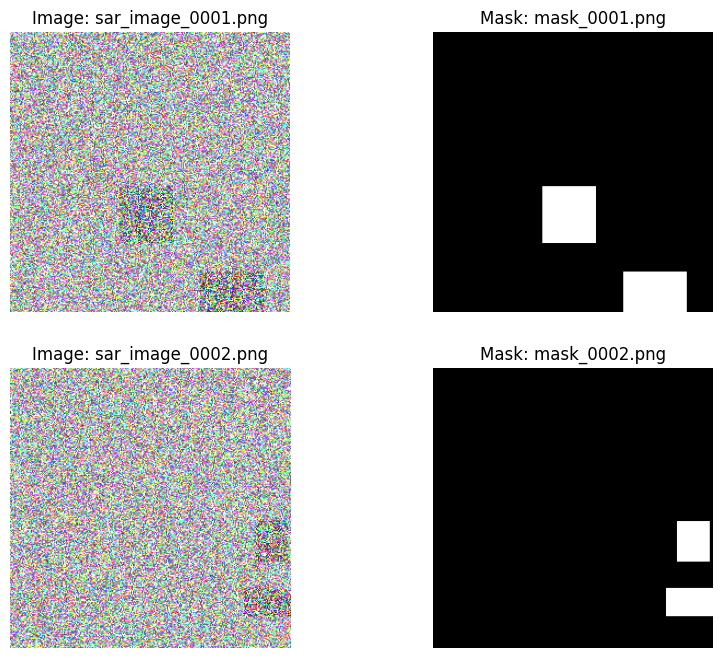

In [ ]:
def show_samples(num=2):
  plt.figure(figsize=(10,4*num))

  for i in range (num):
    imgpath=os.path.join(image_dir,image_files[i])
    labelpath=os.path.join(label_dir,label_files[i])

    img=np.array(Image.open(imgpath))
    label=np.array(Image.open(labelpath))

    plt.subplot(num,2,2*i+1)
    plt.imshow(img,cmap='gray')
    plt.title(f"Image: {image_files[i]}")
    plt.axis('off')

    plt.subplot(num,2,2*i+2)
    plt.imshow(label,cmap='gray')
    plt.title(f"Mask: {label_files[i]}")
    plt.axis('off')

  plt.show()

show_samples(2)

In [ ]:
sample_img=np.array(Image.open(os.path.join(image_dir,image_files[0])))
sample_label=np.array(Image.open(os.path.join(label_dir,label_files[0])))
print("Image Shape: ",sample_img.shape)
print("Label Shape: ",sample_label.shape)

Image Shape:  (256, 256, 3)
Label Shape:  (256, 256, 3)


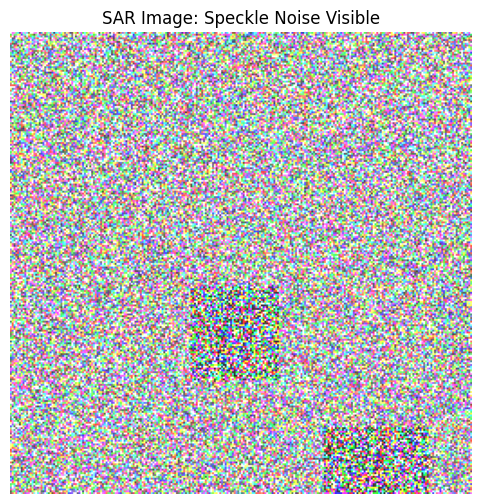

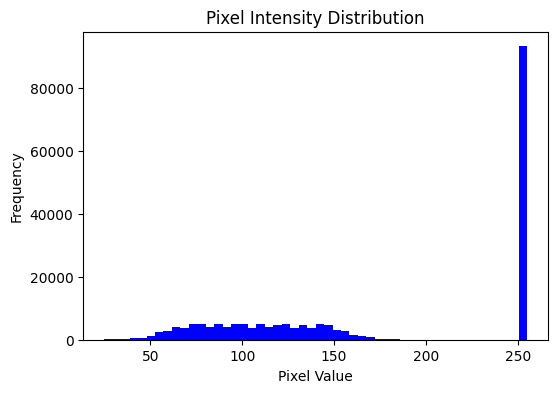

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(sample_img,cmap='gray')
plt.title("SAR Image: Speckle Noise Visible")
plt.axis('off')
plt.show()

plt.figure(figsize=(6,4))
plt.hist(sample_img.flatten(), bins=50, color="blue")
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

In [ ]:
IMG_SIZE=(256,256)

def preprocess_img(img):
    if isinstance(img, np.ndarray):
        img = Image.fromarray(img)
    img=img.resize(IMG_SIZE)
    img_np=np.array(img)
    img_np=img_np/255.0
    img_np=cv2.medianBlur((img_np*255).astype(np.uint8),3)/255.0
    return img_np

def preprocess_label(label):
  if isinstance(label, np.ndarray):
      label = Image.fromarray(label)
  label=label.resize(IMG_SIZE)
  label_np=np.array(label)
  label_np = (label_np > 0).astype(np.uint8)
  return label_np

def augment_img(img):
  return np.fliplr(img)

def augment_label(label):
  return np.fliplr(label)

preprocessed_img=preprocess_img(sample_img)
preprocessed_label=preprocess_label(sample_label)

aug_img=augment_img(preprocessed_img)
aug_label=augment_label(preprocessed_label)